# SBOM & Vulnerability Analysis Dashboard

This notebook analyzes **SBOMs** (Syft), **vulnerability reports** (Grype), **CI/CD workflow risks**, and **SAST findings** (Semgrep) for a GitHub organization.

---

## Analyses Included
1. **Vulnerability Distribution by Severity** — Pie chart
2. **Top 3 Most Insecure Repositories** — Stacked bar chart
3. **Top 5 Guilty Dependencies** — Grouped bar chart
4. **Heatmap: Repos × Severity** — Comparative view
5. **CI/CD Workflow Risk Analysis** — Configuration issues
6. **SAST Findings (Semgrep)** — Code-level vulnerabilities
7. **Qualitative Analysis** — Interpretation & relation to known incidents

## Setup & Data Loading

In [20]:
import json, glob, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({"figure.figsize": (12, 7), "figure.dpi": 100, "axes.titlesize": 16, "axes.titleweight": "bold"})

SEVERITY_COLORS = {"Critical": "#DC2626", "High": "#EA580C", "Medium": "#D97706", "Low": "#65A30D", "Negligible": "#6B7280", "Unknown": "#9CA3AF"}
SEVERITY_ORDER = ["Critical", "High", "Medium", "Low", "Negligible", "Unknown"]

DATA_DIR = "/data"
OUTPUT_DIR = "/home/jovyan/work"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [21]:
def load_vulnerability_data(data_dir):
    records = []
    vuln_files = sorted(glob.glob(os.path.join(data_dir, "vuln_*.json")))
    if not vuln_files:
        print("No vulnerability files found in", data_dir)
        return pd.DataFrame()
    print(f"Loading {len(vuln_files)} vulnerability reports...")
    for filepath in vuln_files:
        filename = Path(filepath).stem
        repo_name = filename.replace("vuln_", "", 1)
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        matches = data.get("matches", [])
        for m in matches:
            vuln = m.get("vulnerability", {})
            artifact = m.get("artifact", {})
            records.append({
                "repository": repo_name,
                "vuln_id": vuln.get("id", ""),
                "severity": vuln.get("severity", "Unknown"),
                "description": vuln.get("description", "")[:200],
                "data_source": vuln.get("dataSource", ""),
                "package_name": artifact.get("name", ""),
                "package_version": artifact.get("version", ""),
                "package_type": artifact.get("type", ""),
            })
    df = pd.DataFrame(records)
    if not df.empty:
        df["severity"] = pd.Categorical(df["severity"], categories=SEVERITY_ORDER, ordered=True)
    print(f"Loaded {len(df):,} vulnerability records from {len(vuln_files)} repos")
    return df

df_vulns = load_vulnerability_data(DATA_DIR)

Loading 5 vulnerability reports...
Loaded 100 vulnerability records from 5 repos


In [22]:
manifest_path = os.path.join(DATA_DIR, "manifest.json")
if os.path.exists(manifest_path):
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    print(f"Organization:          {manifest.get('organization', 'N/A')}")
    print(f"Scan date:             {manifest.get('generated_at', 'N/A')}")
    print(f"Repos processed:       {manifest.get('total_repos_processed', 0)}")
    print(f"SBOMs generated:       {manifest.get('successful_sboms', 0)}")
    print(f"Vuln reports:          {manifest.get('successful_vuln_reports', 0)}")
    print(f"SAST reports:          {manifest.get('successful_sast_reports', 0)}")
    print(f"Workflow analyses:     {manifest.get('successful_workflow_analyses', 0)}")
    print(f"Duration:              {manifest.get('processing_duration_seconds', 0):.1f}s")
else:
    print("No manifest.json found")

Organization:          anthropics
Scan date:             2026-04-24T16:13:57.454671+00:00
Repos processed:       5
SBOMs generated:       5
Vuln reports:          5
SAST reports:          5
Workflow analyses:     5
Duration:              233.5s


---

## 1. Vulnerability Distribution by Severity

Pie chart showing the proportion of total vulnerabilities across severity levels.

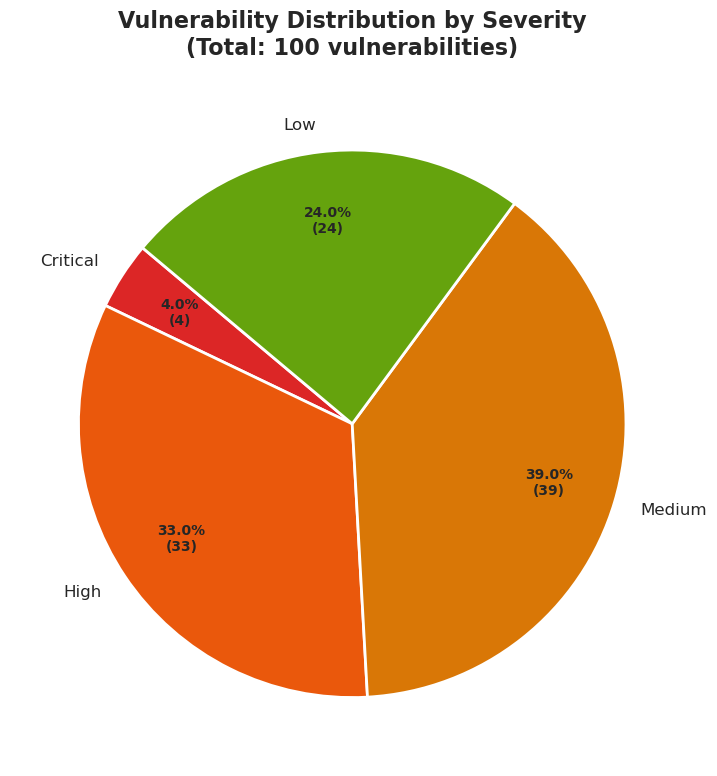


Chart saved to /home/jovyan/work/chart_severity_distribution.png


,Severity,Count,Percentage
0,Critical,4,4.0
1,High,33,33.0
2,Medium,39,39.0
3,Low,24,24.0


In [23]:
if df_vulns.empty:
    print("No data available for analysis.")
else:
    severity_counts = df_vulns["severity"].value_counts().sort_index()
    severity_counts = severity_counts[severity_counts > 0]
    colors = [SEVERITY_COLORS.get(sev, "#9CA3AF") for sev in severity_counts.index]
    fig, ax = plt.subplots(figsize=(10, 8))
    wedges, texts, autotexts = ax.pie(
        severity_counts.values, labels=severity_counts.index, colors=colors,
        autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct / 100.0 * severity_counts.sum()))})",
        startangle=140, pctdistance=0.75,
        wedgeprops={"linewidth": 2, "edgecolor": "white"}, textprops={"fontsize": 12},
    )
    for autotext in autotexts:
        autotext.set_fontsize(10); autotext.set_fontweight("bold")
    ax.set_title(f"Vulnerability Distribution by Severity\n(Total: {severity_counts.sum():,} vulnerabilities)", fontsize=16, fontweight="bold", pad=20)
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_severity_distribution.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"\nChart saved to {chart_path}")
    summary_df = severity_counts.reset_index(); summary_df.columns = ["Severity", "Count"]
    summary_df["Percentage"] = (summary_df["Count"] / summary_df["Count"].sum() * 100).round(1)
    display(summary_df)

---

## 2. Top 3 Most Insecure Repositories

Identifies the repositories with the highest concentration of vulnerabilities, broken down by severity.

-- Top 3 Most Insecure Repositories --



severity,Critical,High,Medium,Low,Total,Risk Score
repository,,,,,,
courses,3,22,15,11,51,119.0
claude-cookbooks,1,11,23,13,48,96.0
prompt-eng-interactive-tutorial,0,0,1,0,1,2.0


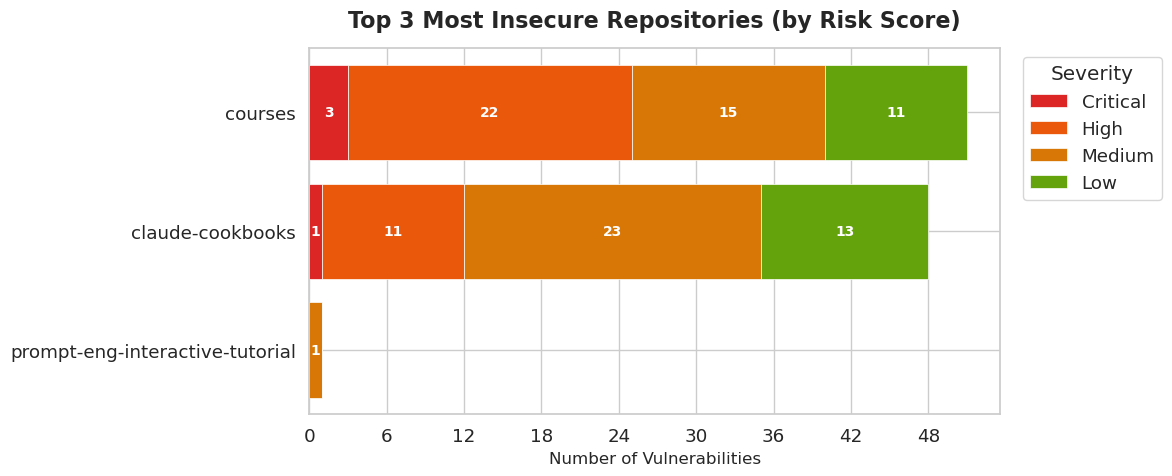


Chart saved to /home/jovyan/work/chart_top3_repos.png


In [5]:
if df_vulns.empty:
    print("No data available for analysis.")
else:
    repo_severity = df_vulns.groupby(["repository", "severity"]).size().unstack(fill_value=0)
    repo_severity["Total"] = repo_severity.sum(axis=1)
    weights = {"Critical": 4, "High": 3, "Medium": 2, "Low": 1, "Negligible": 0.5, "Unknown": 0.5}
    repo_severity["Risk Score"] = sum(repo_severity.get(sev, 0) * w for sev, w in weights.items())
    top3 = repo_severity.sort_values("Risk Score", ascending=False).head(3)
    print("-- Top 3 Most Insecure Repositories --\n"); display(top3)
    severity_cols = [col for col in SEVERITY_ORDER if col in top3.columns]
    plot_data = top3[severity_cols].iloc[::-1]
    fig, ax = plt.subplots(figsize=(12, 5))
    left = pd.Series([0] * len(plot_data), index=plot_data.index)
    for sev in severity_cols:
        values = plot_data[sev]; color = SEVERITY_COLORS.get(sev, "#9CA3AF")
        bars = ax.barh(plot_data.index, values, left=left, label=sev, color=color, edgecolor="white", linewidth=0.5)
        left += values
        for bar, val in zip(bars, values):
            if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, str(int(val)), ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.set_xlabel("Number of Vulnerabilities", fontsize=12)
    ax.set_title("Top 3 Most Insecure Repositories (by Risk Score)", fontsize=16, fontweight="bold", pad=15)
    ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_top3_repos.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"\nChart saved to {chart_path}")

---

## 3. Top 5 Guilty Dependencies

Identifies the 5 specific packages/libraries introducing the most vulnerabilities across the organization.

In [6]:
if df_vulns.empty:
    print("No data available for analysis.")
else:
    pkg_vulns = df_vulns.groupby(["package_name", "package_version", "package_type"]).agg(
        total_vulns=("vuln_id", "count"), critical=("severity", lambda x: (x == "Critical").sum()),
        high=("severity", lambda x: (x == "High").sum()), medium=("severity", lambda x: (x == "Medium").sum()),
        low=("severity", lambda x: (x == "Low").sum()), repos_affected=("repository", "nunique"),
        unique_cves=("vuln_id", "nunique"),
    ).reset_index()
    pkg_vulns["risk_score"] = pkg_vulns["critical"]*4 + pkg_vulns["high"]*3 + pkg_vulns["medium"]*2 + pkg_vulns["low"]*1
    pkg_vulns = pkg_vulns.sort_values(["risk_score", "total_vulns"], ascending=False)
    top5 = pkg_vulns.head(5).copy()
    display_df = top5[["package_name","package_version","package_type","total_vulns","critical","high","medium","low","repos_affected","unique_cves","risk_score"]].copy()
    display_df.columns = ["Package","Version","Type","Total Vulns","Critical","High","Medium","Low","Repos Affected","Unique CVEs","Risk Score"]
    display_df = display_df.reset_index(drop=True); display_df.index = display_df.index + 1; display_df.index.name = "Rank"
    print("-- Top 5 Guilty Dependencies --"); print("(Ranked by weighted risk score)\n")
    def hl(val, cn):
        if cn == "Critical" and val > 0: return "background-color: #FEE2E2; color: #DC2626; font-weight: bold"
        elif cn == "High" and val > 0: return "background-color: #FFEDD5; color: #EA580C; font-weight: bold"
        return ""
    styled = display_df.style.map(lambda v: hl(v, "Critical"), subset=["Critical"]).map(lambda v: hl(v, "High"), subset=["High"]).set_properties(**{"text-align": "center"}).set_properties(subset=["Package"], **{"text-align": "left", "font-weight": "bold"})
    display(styled)

-- Top 5 Guilty Dependencies --
(Ranked by weighted risk score)



,Package,Version,Type,Total Vulns,Critical,High,Medium,Low,Repos Affected,Unique CVEs,Risk Score
Rank,,,,,,,,,,,
1,aiohttp,3.13.2,python,18,0,1,7,10,1,18,27
2,fast-xml-parser,4.4.1,npm,6,1,2,2,1,1,6,15
3,langchain-core,1.1.0,python,4,1,1,1,1,1,4,10
4,basic-ftp,5.0.5,npm,3,1,2,0,0,1,3,10
5,minimatch,9.0.5,npm,3,0,3,0,0,1,3,9


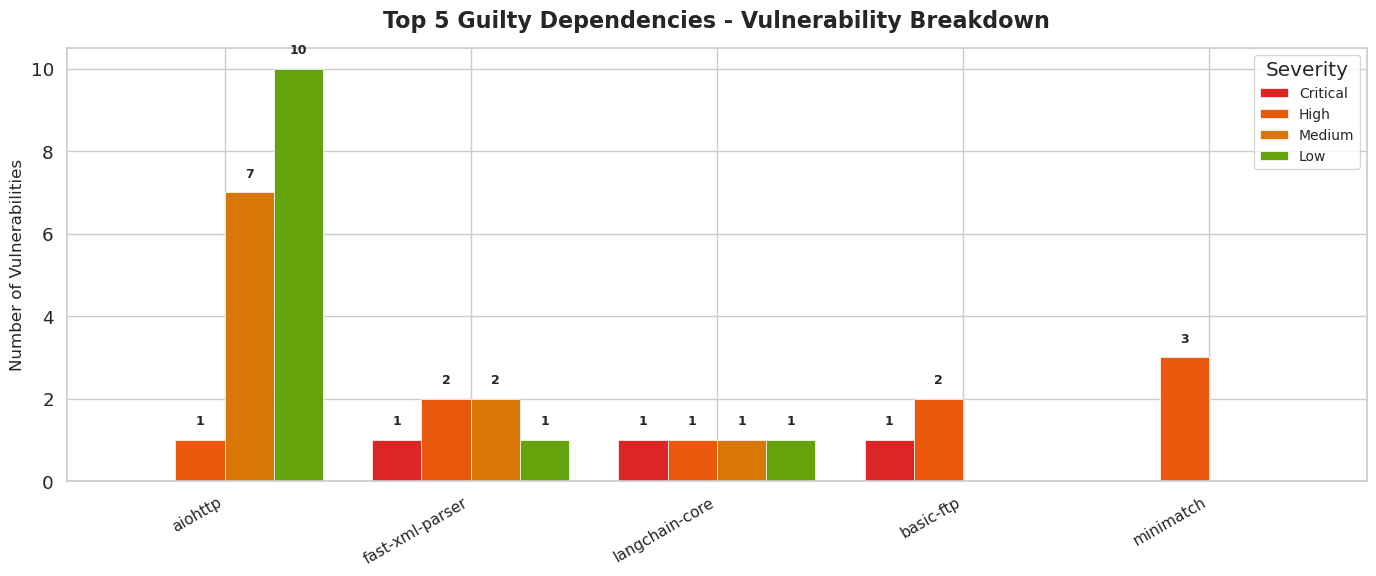


Chart saved to /home/jovyan/work/chart_top5_packages.png


In [7]:
if not df_vulns.empty and not top5.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_pkgs = top5["package_name"].values; x = range(len(plot_pkgs)); bar_width = 0.2
    for i, (sev, color) in enumerate([("critical", SEVERITY_COLORS["Critical"]), ("high", SEVERITY_COLORS["High"]), ("medium", SEVERITY_COLORS["Medium"]), ("low", SEVERITY_COLORS["Low"])]):
        offset = (i - 1.5) * bar_width; values = top5[sev].values
        bars = ax.bar([xi + offset for xi in x], values, width=bar_width, label=sev.capitalize(), color=color, edgecolor="white", linewidth=0.5)
        for bar, val in zip(bars, values):
            if val > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(int(val)), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(list(x)); ax.set_xticklabels(plot_pkgs, rotation=30, ha="right", fontsize=11)
    ax.set_ylabel("Number of Vulnerabilities", fontsize=12)
    ax.set_title("Top 5 Guilty Dependencies - Vulnerability Breakdown", fontsize=16, fontweight="bold", pad=15)
    ax.legend(title="Severity", fontsize=10); ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_top5_packages.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"\nChart saved to {chart_path}")

---

## 4. Heatmap: Repositories × Severity

Comparative view of all analyzed repositories showing vulnerability counts by severity level.

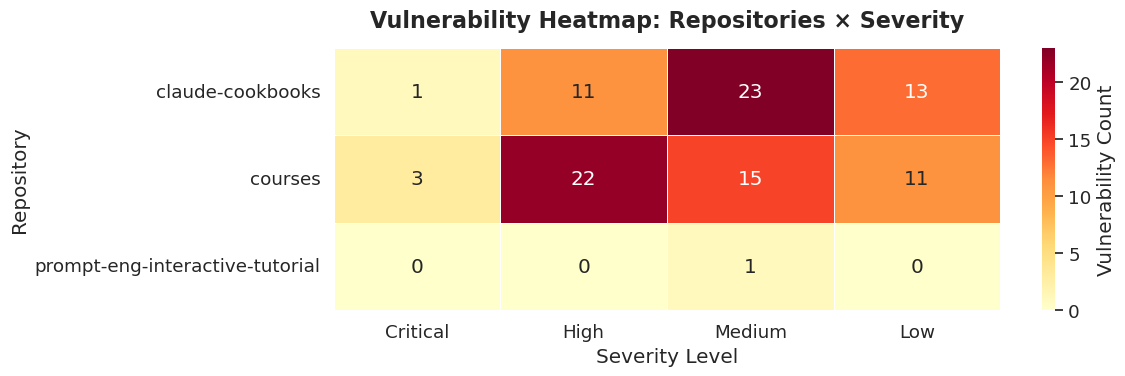

Chart saved to /home/jovyan/work/chart_heatmap.png


In [8]:
if not df_vulns.empty:
    heatmap_data = df_vulns.groupby(["repository", "severity"]).size().unstack(fill_value=0)
    heatmap_data = heatmap_data.reindex(columns=[s for s in SEVERITY_ORDER if s in heatmap_data.columns])
    fig, ax = plt.subplots(figsize=(12, max(4, len(heatmap_data) * 1.2)))
    sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax, cbar_kws={"label": "Vulnerability Count"})
    ax.set_title("Vulnerability Heatmap: Repositories × Severity", fontsize=16, fontweight="bold", pad=15)
    ax.set_ylabel("Repository"); ax.set_xlabel("Severity Level")
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_heatmap.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Chart saved to {chart_path}")
else:
    print("No data for heatmap.")

---

## 5. CI/CD Workflow Risk Analysis

Analysis of GitHub Actions workflow configurations for security risks: dangerous triggers, excessive permissions, unpinned actions, and script injection.

In [9]:
def load_workflow_data(data_dir):
    records = []
    wf_files = sorted(glob.glob(os.path.join(data_dir, "workflows_*.json")))
    if not wf_files:
        print("No workflow analysis files found"); return pd.DataFrame()
    for fp in wf_files:
        with open(fp, "r", encoding="utf-8") as f:
            data = json.load(f)
        repo = data.get("repository", Path(fp).stem.replace("workflows_", ""))
        for finding in data.get("findings", []):
            records.append({"repository": repo, "file": finding.get("file",""), "risk_type": finding.get("risk_type",""), "severity": finding.get("severity","Medium"), "description": finding.get("description","")})
    return pd.DataFrame(records)

df_workflows = load_workflow_data(DATA_DIR)
if df_workflows.empty:
    print("No CI/CD workflow findings detected (this could mean workflows are well-configured or absent).")
else:
    print(f"Loaded {len(df_workflows)} workflow risk findings")
    print(f"\n-- Findings by Risk Type --")
    display(df_workflows["risk_type"].value_counts().to_frame("Count"))
    print(f"\n-- Findings by Repository --")
    display(df_workflows.groupby("repository")["risk_type"].count().to_frame("Findings"))
    print(f"\n-- All Findings --")
    display(df_workflows[["repository","file","risk_type","severity","description"]])

Loaded 21 workflow risk findings

-- Findings by Risk Type --


,Count
risk_type,
unpinned_action,20
broad_write_permission,1



-- Findings by Repository --


,Findings
repository,
claude-code,8
claude-cookbooks,13



-- All Findings --


,repository,file,risk_type,severity,description
0,claude-code,auto-close-duplicates.yml,unpinned_action,Medium,Step 2 uses 'oven-sh/setup-bun@v2' without SHA...
1,claude-code,backfill-duplicate-comments.yml,unpinned_action,Medium,Step 2 uses 'oven-sh/setup-bun@v2' without SHA...
2,claude-code,claude-dedupe-issues.yml,unpinned_action,Medium,Step 2 uses 'anthropics/claude-code-action@v1'...
3,claude-code,claude-issue-triage.yml,unpinned_action,Medium,Step 2 uses 'anthropics/claude-code-action@v1'...
4,claude-code,claude.yml,unpinned_action,Medium,Step 2 uses 'anthropics/claude-code-action@v1'...
5,claude-code,issue-lifecycle-comment.yml,unpinned_action,Medium,Step 2 uses 'oven-sh/setup-bun@v2' without SHA...
6,claude-code,issue-opened-dispatch.yml,broad_write_permission,Medium,Workflow grants write permission on 'actions'
7,claude-code,sweep.yml,unpinned_action,Medium,Step 2 uses 'oven-sh/setup-bun@v2' without SHA...
8,claude-cookbooks,claude-link-review.yml,unpinned_action,Medium,Step 4 uses 'anthropics/claude-code-action@v1'...
9,claude-cookbooks,claude-model-check.yml,unpinned_action,Medium,Step 4 uses 'anthropics/claude-code-action@v1'...


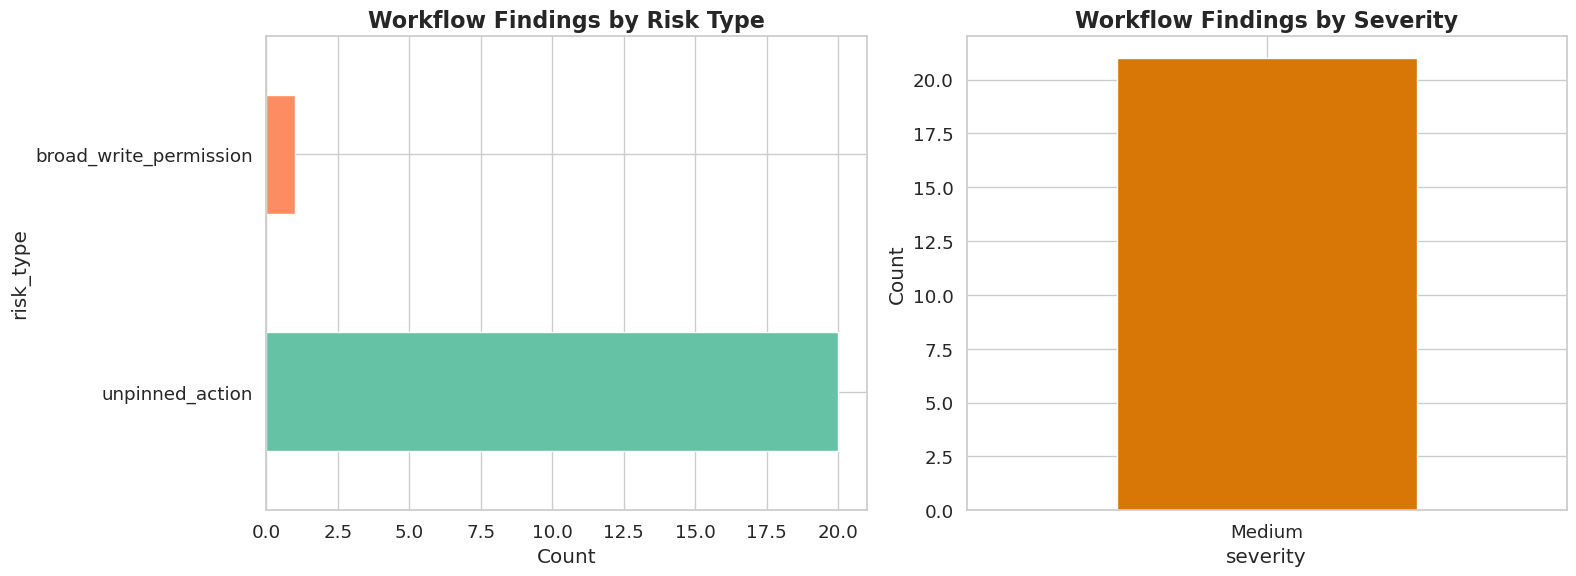

Chart saved to /home/jovyan/work/chart_workflow_risks.png


In [10]:
if not df_workflows.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    # By risk type
    risk_counts = df_workflows["risk_type"].value_counts()
    colors_rt = sns.color_palette("Set2", len(risk_counts))
    risk_counts.plot(kind="barh", ax=axes[0], color=colors_rt, edgecolor="white")
    axes[0].set_title("Workflow Findings by Risk Type", fontweight="bold")
    axes[0].set_xlabel("Count")
    # By severity
    sev_counts = df_workflows["severity"].value_counts()
    sev_colors = [SEVERITY_COLORS.get(s, "#9CA3AF") for s in sev_counts.index]
    sev_counts.plot(kind="bar", ax=axes[1], color=sev_colors, edgecolor="white")
    axes[1].set_title("Workflow Findings by Severity", fontweight="bold")
    axes[1].set_ylabel("Count"); axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_workflow_risks.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Chart saved to {chart_path}")

---

## 6. SAST Findings (Semgrep)

Static Application Security Testing results from Semgrep, identifying potential code-level vulnerabilities.

In [11]:
def load_sast_data(data_dir):
    records = []
    sast_files = sorted(glob.glob(os.path.join(data_dir, "sast_*.json")))
    if not sast_files:
        print("No SAST files found"); return pd.DataFrame()
    for fp in sast_files:
        repo = Path(fp).stem.replace("sast_", "")
        with open(fp, "r", encoding="utf-8") as f:
            data = json.load(f)
        for result in data.get("results", []):
            extra = result.get("extra", {})
            metadata = extra.get("metadata", {})
            records.append({
                "repository": repo, "rule_id": result.get("check_id", ""),
                "severity": extra.get("severity", "INFO").capitalize(),
                "message": extra.get("message", "")[:150],
                "file": result.get("path", ""),
                "line": result.get("start", {}).get("line", 0),
                "category": metadata.get("category", "unknown"),
                "confidence": metadata.get("confidence", "unknown"),
            })
    return pd.DataFrame(records)

df_sast = load_sast_data(DATA_DIR)
if df_sast.empty:
    print("No SAST findings detected (either Semgrep found no issues or didn't run).")
else:
    print(f"Loaded {len(df_sast)} SAST findings from Semgrep")
    print(f"\n-- Findings by Severity --")
    display(df_sast["severity"].value_counts().to_frame("Count"))
    print(f"\n-- Findings by Category --")
    display(df_sast["category"].value_counts().head(10).to_frame("Count"))
    print(f"\n-- Top Findings --")
    display(df_sast[["repository","severity","rule_id","file","line","message"]].head(20))

Loaded 47 SAST findings from Semgrep

-- Findings by Severity --


,Count
severity,
Error,28
Warning,18
Info,1



-- Findings by Category --


,Count
category,
security,47



-- Top Findings --


,repository,severity,rule_id,file,line,message
0,claude-code,Warning,dockerfile.security.no-sudo-in-dockerfile.no-s...,/tmp/sbom_claude-code_7df8tcdx/.devcontainer/D...,52,Avoid using sudo in Dockerfiles. Running proce...
1,claude-code,Warning,bash.lang.security.ifs-tampering.ifs-tampering,/tmp/sbom_claude-code_7df8tcdx/.devcontainer/i...,3,The special variable IFS affects how splitting...
2,claude-code,Error,yaml.github-actions.security.run-shell-injecti...,/tmp/sbom_claude-code_7df8tcdx/.github/workflo...,41,Using variable interpolation `${{...}}` with `...
3,claude-cookbooks,Error,yaml.github-actions.security.run-shell-injecti...,/tmp/sbom_claude-cookbooks_x750cfna/.github/wo...,29,Using variable interpolation `${{...}}` with `...
4,claude-cookbooks,Error,yaml.github-actions.security.run-shell-injecti...,/tmp/sbom_claude-cookbooks_x750cfna/.github/wo...,30,Using variable interpolation `${{...}}` with `...
5,claude-cookbooks,Error,yaml.github-actions.security.run-shell-injecti...,/tmp/sbom_claude-cookbooks_x750cfna/.github/wo...,30,Using variable interpolation `${{...}}` with `...
6,claude-cookbooks,Warning,python.lang.security.deserialization.pickle.av...,/tmp/sbom_claude-cookbooks_x750cfna/capabiliti...,80,"Avoid using `pickle`, which is known to lead t..."
7,claude-cookbooks,Warning,python.aws-lambda.security.tainted-html-string...,/tmp/sbom_claude-cookbooks_x750cfna/capabiliti...,70,Detected user input flowing into a manually co...
8,claude-cookbooks,Warning,python.lang.security.deserialization.pickle.av...,/tmp/sbom_claude-cookbooks_x750cfna/capabiliti...,78,"Avoid using `pickle`, which is known to lead t..."
9,claude-cookbooks,Warning,python.lang.security.deserialization.pickle.av...,/tmp/sbom_claude-cookbooks_x750cfna/capabiliti...,86,"Avoid using `pickle`, which is known to lead t..."


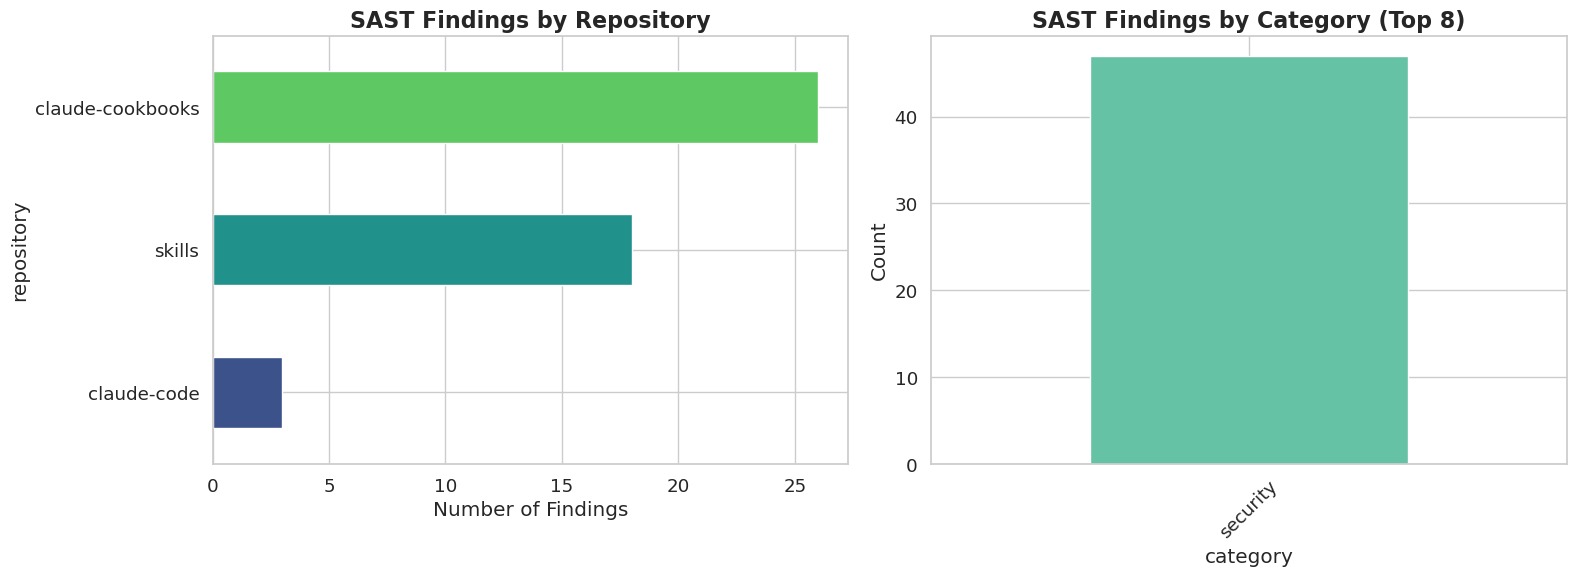

Chart saved to /home/jovyan/work/chart_sast_findings.png


In [12]:
if not df_sast.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    repo_sast = df_sast.groupby("repository").size().sort_values(ascending=True)
    repo_sast.plot(kind="barh", ax=axes[0], color=sns.color_palette("viridis", len(repo_sast)), edgecolor="white")
    axes[0].set_title("SAST Findings by Repository", fontweight="bold"); axes[0].set_xlabel("Number of Findings")
    cat_counts = df_sast["category"].value_counts().head(8)
    cat_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", len(cat_counts)), edgecolor="white")
    axes[1].set_title("SAST Findings by Category (Top 8)", fontweight="bold")
    axes[1].set_ylabel("Count"); axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "chart_sast_findings.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Chart saved to {chart_path}")

---

## Full Vulnerability Data Export

Export the complete dataset to CSV for further analysis.

In [13]:
if not df_vulns.empty:
    csv_path = os.path.join(OUTPUT_DIR, "all_vulnerabilities.csv")
    df_vulns.to_csv(csv_path, index=False)
    print(f"Full dataset exported to {csv_path}")
    print(f"   Total records: {len(df_vulns):,}")
    print(f"   Columns: {', '.join(df_vulns.columns)}")
else:
    print("No data to export.")

Full dataset exported to /home/jovyan/work/all_vulnerabilities.csv
   Total records: 100
   Columns: repository, vuln_id, severity, description, data_source, package_name, package_version, package_type


---

## 7. Qualitative Analysis

### 7.1 Justification for Organization Selection

> **TODO (Completar):** Explica por qué elegiste la organización `anthropics`. Considera:
> - Relevancia del proyecto en el ecosistema de software
> - Impacto potencial de las vulnerabilidades encontradas
> - Relación con el caso de la tabla: "Anthropic MCP SDK — Uso de entradas no sanitizadas que permiten ejecutar comandos (2026)"

### 7.2 Interpretation of Results

> **TODO (Completar):** Basándote en los datos cuantitativos anteriores, interpreta:
> - ¿Cuáles son los patrones más notables en la distribución de vulnerabilidades?
> - ¿Los repos más populares son también los más vulnerables? ¿Por qué?
> - ¿Qué tipos de dependencias introducen más riesgo?

### 7.3 Relation to Known Incidents

> **TODO (Completar):** Relaciona tus hallazgos con los casos de la tabla de la tarea:
> - ¿Encontraste evidencia de entradas no sanitizadas (similar al caso MCP SDK)?
> - ¿Los workflows tienen configuraciones riesgosas (similar al caso de GitHub Actions)?
> - ¿Hay dependencias que podrían ser vectores de ataque como en el caso de Apache Maven?
> - ¿Algún hallazgo es similar a la exposición de secretos de tj-actions?

### 7.4 Local vs. Systemic Problems

> **TODO (Completar):** Reflexiona sobre si los problemas encontrados son:
> - **Problemas locales**: específicos de las prácticas de desarrollo de esta organización
> - **Problemas sistémicos**: reflejan condiciones más amplias del ecosistema de software
> - Argumenta con evidencia de tus hallazgos

---

## 8. Summary Table

In [14]:
if not df_vulns.empty:
    summary_rows = []
    for repo in df_vulns["repository"].unique():
        repo_df = df_vulns[df_vulns["repository"] == repo]
        wf_count = len(df_workflows[df_workflows["repository"] == repo]) if not df_workflows.empty else 0
        sast_count = len(df_sast[df_sast["repository"] == repo]) if not df_sast.empty else 0
        summary_rows.append({
            "Repository": repo,
            "Total Vulns": len(repo_df),
            "Critical": (repo_df["severity"] == "Critical").sum(),
            "High": (repo_df["severity"] == "High").sum(),
            "Medium": (repo_df["severity"] == "Medium").sum(),
            "Low": (repo_df["severity"] == "Low").sum(),
            "Unique Packages": repo_df["package_name"].nunique(),
            "Workflow Risks": wf_count,
            "SAST Findings": sast_count,
        })
    summary_df = pd.DataFrame(summary_rows).set_index("Repository")
    print("-- Comparative Summary of All Repositories --\n")
    display(summary_df.style.background_gradient(cmap="YlOrRd", subset=["Critical","High"]).set_properties(**{"text-align":"center"}))
    csv_summary = os.path.join(OUTPUT_DIR, "summary_table.csv")
    summary_df.to_csv(csv_summary)
    print(f"\nSummary exported to {csv_summary}")
else:
    print("No data for summary.")

-- Comparative Summary of All Repositories --



,Total Vulns,Critical,High,Medium,Low,Unique Packages,Workflow Risks,SAST Findings
Repository,,,,,,,,
claude-cookbooks,48,1,11,23,13,18,13,26
courses,51,3,22,15,11,30,0,0
prompt-eng-interactive-tutorial,1,0,0,1,0,1,0,0



Summary exported to /home/jovyan/work/summary_table.csv
